# Exploratory Data Analysis

INT 374 - PCOS Prediction Project

Creating visualizations to understand the dataset better.
Looking at distributions, correlations, and relationships between features and the target.

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
plt.style.use('default')

# Load cleaned data
df = pd.read_csv('../data/PCOS_cleaned.csv')
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Loaded: 541 rows, 42 columns


In [3]:
# Categorize features
target = 'PCOS'
numeric_cols = df.select_dtypes(include='number').columns
binary_features = [col for col in df.columns if df[col].nunique() == 2 and col != target]
continuous_features = [col for col in numeric_cols if df[col].nunique() > 10 and col != target]
discrete_features = [col for col in numeric_cols if 3 <= df[col].nunique() <= 10 and col != target]

print(f'Binary: {len(binary_features)}')
print(f'Continuous: {len(continuous_features)}')
print(f'Discrete: {len(discrete_features)}')

Binary: 8
Continuous: 27
Discrete: 6


## Target Distribution

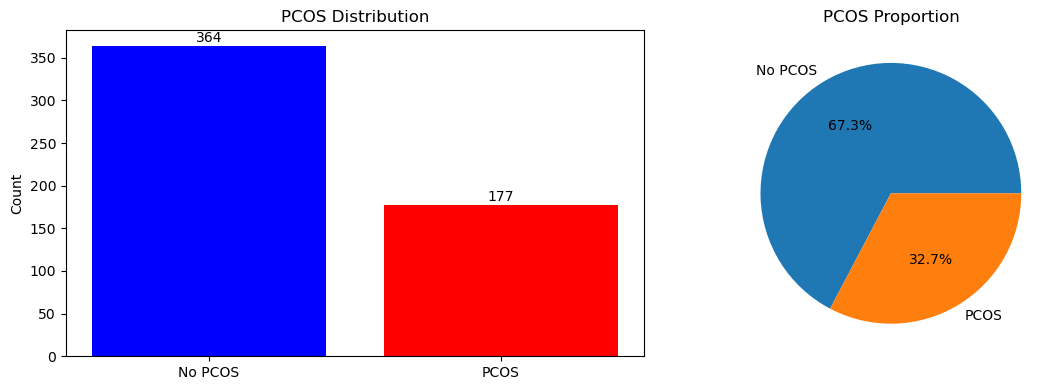

Saved target distribution plot


In [4]:
# Plot target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df[target].value_counts()
axes[0].bar(['No PCOS', 'PCOS'], [counts[0], counts[1]], color=['blue', 'red'])
axes[0].set_ylabel('Count')
axes[0].set_title('PCOS Distribution')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Pie chart
axes[1].pie(counts.values, labels=['No PCOS', 'PCOS'], autopct='%1.1f%%')
axes[1].set_title('PCOS Proportion')

plt.tight_layout()
plt.savefig('../outputs/figures/04_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved target distribution plot')

## Feature Distributions

In [ ]:
# Plot distributions for continuous features
n = len(continuous_features)
n_cols = 4
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(continuous_features):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(col)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(continuous_features), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/05_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature distributions')

## Correlation Analysis

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 14))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, 
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/06_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved correlation heatmap')

## Features vs Target

In [ ]:
# Correlation with target
target_corr = df.corr()[target].sort_values(ascending=False)
target_corr = target_corr[target_corr.index != target]

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=colors)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=9)
ax.set_xlabel('Correlation with PCOS')
ax.set_title('Feature Correlation with Target')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/07_target_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved target correlation bar plot')

## QQ Plots for Normality

In [ ]:
# QQ plots for key features
key_features = continuous_features[:8]
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    stats.probplot(df[col], dist="norm", plot=axes[idx])
    axes[idx].set_title(f'QQ Plot - {col}')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/21_qq_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved QQ plots')

## Radar Chart

In [ ]:
# Normalize features for radar plot
from sklearn.preprocessing import MinMaxScaler

radar_features = ['Weight_Gain', 'Hair_Growth', 'Skin_Darkening', 'Weight_Kg', 'Pimples', 'Fast_Food', 'Cycle_RI']
radar_features = [f for f in radar_features if f in df.columns]

scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df[radar_features]),
    columns=radar_features
)

# Calculate means by PCOS status
pcos_0_mean = df_normalized[df['PCOS'] == 0].mean()
pcos_1_mean = df_normalized[df['PCOS'] == 1].mean()

# Radar plot
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

pcos_0_values = pcos_0_mean.tolist()
pcos_0_values += pcos_0_values[:1]

pcos_1_values = pcos_1_mean.tolist()
pcos_1_values += pcos_1_values[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
ax.plot(angles, pcos_0_values, 'o-', linewidth=2, label='No PCOS', color='blue')
ax.fill(angles, pcos_0_values, alpha=0.25, color='blue')

ax.plot(angles, pcos_1_values, 'o-', linewidth=2, label='PCOS', color='red')
ax.fill(angles, pcos_1_values, alpha=0.25, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('PCOS vs Non-PCOS Comparison', fontsize=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('../outputs/figures/19_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved radar chart')

## Box Plots by Target

In [ ]:
# Box plots for top features
top_features = continuous_features[:8]
n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 8))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    pcos_0 = df[df['PCOS'] == 0][col]
    pcos_1 = df[df['PCOS'] == 1][col]
    axes[idx].boxplot([pcos_0, pcos_1], labels=['No PCOS', 'PCOS'])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/08_boxplots_top_features.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved box plots')

## Statistical Summary

In [ ]:
# Descriptive statistics by PCOS status
print('Mean values by PCOS status:')
comparison = df.groupby('PCOS')[continuous_features].mean().T
comparison.columns = ['No PCOS', 'PCOS']
comparison['Difference'] = comparison['PCOS'] - comparison['No PCOS']
comparison['% Change'] = ((comparison['Difference'] / comparison['No PCOS']) * 100).round(2)
print(comparison.sort_values('% Change', ascending=False).head(15))

In [ ]:
print('EDA completed')

# 2. Exploratory Data Analysis & Visualization
**INT 374 — Data Science Toolbox: Python Programming**  
**Project: PCOS (Polycystic Ovary Syndrome) Prediction**

This notebook generates 20+ professional visualizations covering:
- Target distribution, missing data, distributions
- Correlation heatmaps, feature-vs-target analysis
- Hormonal profiles, lifestyle factors, follicle analysis
- Pair plots, QQ plots, radar charts

## 2.1 Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 7),
    'font.size': 12,
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.family': 'sans-serif'
})

os.makedirs('../outputs/figures', exist_ok=True)

# Load cleaned dataset
df = pd.read_csv('../data/PCOS_cleaned.csv')
print(f"✅ Loaded cleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Missing values: {df.isnull().sum().sum()}")

# Categorize features
target = 'PCOS'
binary_features = [c for c in df.columns if df[c].nunique() == 2 and c != target]
continuous_features = [c for c in df.select_dtypes(include='number').columns if df[c].nunique() > 10 and c != target]
discrete_features = [c for c in df.select_dtypes(include='number').columns if 3 <= df[c].nunique() <= 10 and c != target]

COLORS = {'pcos': '#E74C3C', 'non_pcos': '#3498DB', 'accent': '#2ECC71'}
PALETTE = [COLORS['non_pcos'], COLORS['pcos']]

print(f"   Binary: {len(binary_features)}, Continuous: {len(continuous_features)}, Discrete: {len(discrete_features)}")

---
## 2.2 Target Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df[target].value_counts()
labels = ['Non-PCOS (0)', 'PCOS (1)']
bars = axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=2, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('PCOS Diagnosis Distribution', fontsize=15, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05), shadow=True,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('PCOS Class Proportion', fontsize=15, fontweight='bold')

plt.suptitle('Figure 1: Target Variable Distribution', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/04_target_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 04_target_distribution.png")

---
## 2.3 Distribution Plots (All Continuous Features)

In [ ]:
n = len(continuous_features)
n_cols = 4
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(continuous_features):
    for label, color in zip([0, 1], PALETTE):
        subset = df[df[target] == label][col].dropna()
        axes[idx].hist(subset, bins=25, alpha=0.55, color=color, edgecolor='white',
                       label=f"{'Non-PCOS' if label == 0 else 'PCOS'}")
        subset.plot.kde(ax=axes[idx], color=color, linewidth=2)
    axes[idx].set_title(col, fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=8)
    axes[idx].tick_params(labelsize=8)

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Figure 2: Feature Distributions by PCOS Status (Histogram + KDE)', 
             fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/05_feature_distributions.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 05_feature_distributions.png")

---
## 2.4 Correlation Heatmap (Full Features)

In [ ]:
fig, ax = plt.subplots(figsize=(22, 18))
corr = df.select_dtypes(include='number').corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, center=0, annot=True, fmt='.2f',
            square=True, linewidths=0.5, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'}, ax=ax)
ax.set_title('Figure 3: Feature Correlation Heatmap', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/06_correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 06_correlation_heatmap.png")

---
## 2.5 Top Features Correlated with Target

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
target_corr = corr[target].drop(target).sort_values(ascending=True)

colors = ['#E74C3C' if v > 0 else '#3498DB' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, target_corr.values):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9, fontweight='bold')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Figure 4: Feature Correlation with PCOS (Target)', fontsize=15, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/07_target_correlation_bar.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 07_target_correlation_bar.png")

---
## 2.6 Box Plots — Feature vs Target

In [ ]:
top_features = target_corr.abs().sort_values(ascending=False).head(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(22, 15))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    sns.boxplot(data=df, x=target, y=col, ax=axes[idx], palette=PALETTE,
                hue=target, legend=False, width=0.5)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels(['Non-PCOS', 'PCOS'])

plt.suptitle('Figure 5: Box Plots — Top 12 Features by PCOS Status', 
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/08_boxplots_top_features.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 08_boxplots_top_features.png")

---
## 2.7 Violin Plots — Key Hormonal Features

In [ ]:
hormonal = ['FSH', 'LH', 'TSH', 'AMH', 'Prolactin', 'Progesterone', 'Beta_HCG_I', 'Beta_HCG_II']
hormonal = [h for h in hormonal if h in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(hormonal):
    sns.violinplot(data=df, x=target, y=col, ax=axes[idx], palette=PALETTE,
                   hue=target, legend=False, inner='quartile', cut=0)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels(['Non-PCOS', 'PCOS'])

for idx in range(len(hormonal), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Figure 6: Violin Plots — Hormonal Profiles by PCOS Status',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/09_violin_hormonal.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 09_violin_hormonal.png")

---
## 2.8 Pair Plot — Top 5 Features

In [ ]:
top5 = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()
pair_df = df[top5 + [target]].copy()
pair_df[target] = pair_df[target].map({0: 'Non-PCOS', 1: 'PCOS'})

g = sns.pairplot(pair_df, hue=target, palette={'Non-PCOS': PALETTE[0], 'PCOS': PALETTE[1]},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30}, corner=True)
g.figure.suptitle('Figure 7: Pair Plot — Top 5 Correlated Features', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('../outputs/figures/10_pairplot_top5.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 10_pairplot_top5.png")

---
## 2.9 Binary / Categorical Feature Analysis

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
axes = axes.flatten()

for idx, col in enumerate(binary_features[:10]):
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[idx], color=PALETTE, edgecolor='white', width=0.5)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].set_xlabel('')
    axes[idx].set_xticklabels(['No (0)', 'Yes (1)'], rotation=0)
    axes[idx].legend(['Non-PCOS', 'PCOS'], fontsize=8)
    axes[idx].set_ylim(0, 100)

for idx in range(len(binary_features[:10]), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Figure 8: Binary Features — PCOS Prevalence (%)', 
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/11_binary_features_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 11_binary_features_analysis.png")

---
## 2.10 Age vs BMI Scatter Plot

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]
    ax.scatter(subset['Age'], subset['BMI'], c=color, alpha=0.5, s=50, label=name, edgecolors='white')

ax.set_xlabel('Age (years)', fontsize=13)
ax.set_ylabel('BMI', fontsize=13)
ax.set_title('Figure 9: Age vs BMI by PCOS Status', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/12_age_vs_bmi.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 12_age_vs_bmi.png")

---
## 2.11 BMI Distribution by PCOS Status

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]['BMI']
    ax.hist(subset, bins=30, alpha=0.5, color=color, edgecolor='white', label=name)
    subset.plot.kde(ax=ax, color=color, linewidth=2.5)

ax.axvline(x=25, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Overweight threshold (25)')
ax.axvline(x=30, color='darkred', linestyle='--', linewidth=1.5, alpha=0.7, label='Obese threshold (30)')
ax.set_title('Figure 10: BMI Distribution by PCOS Status', fontsize=15, fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Density / Count')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/13_bmi_distribution.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 13_bmi_distribution.png")

---
## 2.12 Follicle Analysis — Left vs Right

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left follicle
sns.boxplot(data=df, x=target, y='Follicle_L', ax=axes[0], palette=PALETTE,
            hue=target, legend=False, width=0.4)
axes[0].set_title('Left Follicle Count', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Non-PCOS', 'PCOS'])
axes[0].set_xlabel('')

# Right follicle
sns.boxplot(data=df, x=target, y='Follicle_R', ax=axes[1], palette=PALETTE,
            hue=target, legend=False, width=0.4)
axes[1].set_title('Right Follicle Count', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Non-PCOS', 'PCOS'])
axes[1].set_xlabel('')

# Scatter L vs R
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]
    axes[2].scatter(subset['Follicle_L'], subset['Follicle_R'], c=color, alpha=0.5, s=40,
                    label=name, edgecolors='white')
axes[2].plot([0, 22], [0, 22], 'k--', alpha=0.3, label='Equal count line')
axes[2].set_xlabel('Follicle Count (Left)')
axes[2].set_ylabel('Follicle Count (Right)')
axes[2].set_title('Left vs Right Follicle', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Figure 11: Follicle Analysis by PCOS Status', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/14_follicle_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 14_follicle_analysis.png")

---
## 2.13 Waist-Hip Ratio Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Waist-Hip Ratio distribution
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]['Waist_Hip_Ratio']
    axes[0].hist(subset, bins=25, alpha=0.5, color=color, edgecolor='white', label=name)
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)

axes[0].axvline(x=0.85, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Risk threshold (0.85)')
axes[0].set_title('Waist-Hip Ratio Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Waist:Hip Ratio')
axes[0].legend(fontsize=9)

# Waist vs Hip scatter
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]
    axes[1].scatter(subset['Waist'], subset['Hip'], c=color, alpha=0.5, s=40, 
                    label=name, edgecolors='white')
axes[1].set_xlabel('Waist (inch)')
axes[1].set_ylabel('Hip (inch)')
axes[1].set_title('Waist vs Hip Measurements', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.suptitle('Figure 12: Waist-Hip Analysis by PCOS Status', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/15_waist_hip_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 15_waist_hip_analysis.png")

---
## 2.14 Blood Pressure Analysis

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Systolic vs Diastolic
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]
    axes[0].scatter(subset['BP_Systolic'], subset['BP_Diastolic'], c=color, 
                    alpha=0.5, s=50, label=name, edgecolors='white')
axes[0].set_xlabel('Systolic BP (mmHg)', fontsize=12)
axes[0].set_ylabel('Diastolic BP (mmHg)', fontsize=12)
axes[0].set_title('Systolic vs Diastolic BP', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Box plots side-by-side
bp_data = df.melt(id_vars=[target], value_vars=['BP_Systolic', 'BP_Diastolic'],
                  var_name='BP_Type', value_name='mmHg')
sns.boxplot(data=bp_data, x='BP_Type', y='mmHg', hue=target, ax=axes[1], palette=PALETTE)
axes[1].set_title('Blood Pressure by PCOS Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].legend(title='PCOS', labels=['Non-PCOS', 'PCOS'])

plt.suptitle('Figure 13: Blood Pressure Analysis', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/16_blood_pressure.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 16_blood_pressure.png")

---
## 2.15 Lifestyle Factors Heatmap

In [ ]:
lifestyle = ['Weight_Gain', 'Hair_Growth', 'Skin_Darkening', 'Hair_Loss', 'Pimples', 'Fast_Food', 'Regular_Exercise']
lifestyle = [l for l in lifestyle if l in df.columns]

# Calculate percentage of Yes for each lifestyle factor by PCOS status
lifestyle_pct = df.groupby(target)[lifestyle].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(lifestyle_pct, annot=True, fmt='.1f', cmap='RdYlBu_r', 
            linewidths=1, linecolor='white', ax=ax,
            xticklabels=[l.replace('_', ' ') for l in lifestyle],
            yticklabels=['Non-PCOS', 'PCOS'],
            cbar_kws={'label': 'Percentage (%)'})
ax.set_title('Figure 14: Lifestyle Factors — Prevalence (%) by PCOS Status', 
             fontsize=15, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../outputs/figures/17_lifestyle_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 17_lifestyle_heatmap.png")

---
## 2.16 Hormonal Profile — Grouped Bar Charts

In [ ]:
hormonal_key = ['FSH', 'LH', 'TSH', 'AMH', 'Prolactin', 'Progesterone']
hormonal_key = [h for h in hormonal_key if h in df.columns]

means = df.groupby(target)[hormonal_key].mean()

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(hormonal_key))
width = 0.35

bars1 = ax.bar(x - width/2, means.loc[0], width, label='Non-PCOS', color=PALETTE[0], edgecolor='white')
bars2 = ax.bar(x + width/2, means.loc[1], width, label='PCOS', color=PALETTE[1], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(hormonal_key, fontsize=12)
ax.set_ylabel('Mean Value', fontsize=12)
ax.set_title('Figure 15: Hormonal Profile — Mean Values by PCOS Status', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/figures/18_hormonal_profile.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 18_hormonal_profile.png")

---
## 2.17 Radar Chart — Feature Spread PCOS vs Non-PCOS

In [ ]:
# Select top features for radar chart
radar_features = target_corr.abs().sort_values(ascending=False).head(8).index.tolist()

# Normalize values to 0-1 for radar chart
means_0 = df[df[target] == 0][radar_features].mean()
means_1 = df[df[target] == 1][radar_features].mean()
combined = pd.concat([means_0, means_1], axis=1)
combined.columns = ['Non-PCOS', 'PCOS']
normalized = (combined - combined.min()) / (combined.max() - combined.min())

# Radar chart
angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for col, color, name in zip(['Non-PCOS', 'PCOS'], PALETTE, ['Non-PCOS', 'PCOS']):
    values = normalized[col].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', color=color, linewidth=2, label=name)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_thetagrids(np.degrees(angles[:-1]), radar_features, fontsize=10)
ax.set_title('Figure 16: Feature Radar — PCOS vs Non-PCOS (Normalized)', 
             fontsize=15, fontweight='bold', pad=30)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('../outputs/figures/19_radar_chart.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 19_radar_chart.png")

---
## 2.18 Outlier Summary Chart

In [ ]:
def count_outliers_iqr(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)).sum()

outlier_counts = {col: count_outliers_iqr(df[col]) for col in continuous_features}
outlier_df = pd.DataFrame(list(outlier_counts.items()), columns=['Feature', 'Outlier_Count'])
outlier_df = outlier_df[outlier_df['Outlier_Count'] > 0].sort_values('Outlier_Count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(outlier_df['Feature'], outlier_df['Outlier_Count'], 
               color=sns.color_palette('YlOrRd', len(outlier_df)), edgecolor='white')

for bar, val in zip(bars, outlier_df['Outlier_Count']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, str(val), 
            va='center', fontweight='bold', fontsize=10)

ax.set_title('Figure 17: Outlier Count per Feature (IQR Method)', fontsize=15, fontweight='bold')
ax.set_xlabel('Number of Outliers')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/20_outlier_summary.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 20_outlier_summary.png")

---
## 2.19 QQ Plots — Normality Check

In [ ]:
key_features = ['BMI', 'Age', 'FSH', 'LH', 'AMH', 'Hemoglobin', 'Weight_Kg', 'TSH']
key_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, col in enumerate(key_features):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[idx])
    axes[idx].set_title(f'QQ Plot: {col}', fontsize=12, fontweight='bold')
    axes[idx].get_lines()[0].set_color(PALETTE[0])
    axes[idx].get_lines()[0].set_markersize(3)
    axes[idx].get_lines()[1].set_color(COLORS['pcos'])

for idx in range(len(key_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Figure 18: QQ Plots — Normality Check for Key Features',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/21_qq_plots.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 21_qq_plots.png")

---
## 2.20 Count Plots — Discrete Features

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

all_discrete = discrete_features + [f for f in binary_features if f not in discrete_features]
plot_cols = all_discrete[:8]

for idx, col in enumerate(plot_cols):
    sns.countplot(data=df, x=col, hue=target, ax=axes[idx], palette=PALETTE)
    axes[idx].set_title(col, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].legend(title='PCOS', labels=['No', 'Yes'], fontsize=8)

for idx in range(len(plot_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Figure 19: Count Plots — Discrete & Binary Features by PCOS',
             fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/22_count_plots.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 22_count_plots.png")

---
## 2.21 Weight & Height Analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Weight distribution
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]['Weight_Kg']
    axes[0].hist(subset, bins=25, alpha=0.5, color=color, edgecolor='white', label=name)
    subset.plot.kde(ax=axes[0], color=color, linewidth=2)
axes[0].set_title('Weight Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Weight (Kg)')
axes[0].legend(fontsize=10)

# Height distribution
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]['Height_Cm']
    axes[1].hist(subset, bins=25, alpha=0.5, color=color, edgecolor='white', label=name)
    subset.plot.kde(ax=axes[1], color=color, linewidth=2)
axes[1].set_title('Height Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Height (Cm)')
axes[1].legend(fontsize=10)

# Weight vs Height scatter
for label, color, name in zip([0, 1], PALETTE, ['Non-PCOS', 'PCOS']):
    subset = df[df[target] == label]
    axes[2].scatter(subset['Height_Cm'], subset['Weight_Kg'], c=color, alpha=0.5, s=40,
                    label=name, edgecolors='white')
axes[2].set_xlabel('Height (Cm)')
axes[2].set_ylabel('Weight (Kg)')
axes[2].set_title('Weight vs Height', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)

plt.suptitle('Figure 20: Weight & Height Analysis', fontsize=17, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('../outputs/figures/23_weight_height.png', dpi=200, bbox_inches='tight')
plt.show()
print("💾 Saved: 23_weight_height.png")

---
## 2.22 Summary Statistics Table

In [ ]:
# Pretty summary table
summary = pd.DataFrame({
    'Feature': continuous_features,
    'Mean (Non-PCOS)': [df[df[target]==0][c].mean() for c in continuous_features],
    'Mean (PCOS)': [df[df[target]==1][c].mean() for c in continuous_features],
    'Std (Non-PCOS)': [df[df[target]==0][c].std() for c in continuous_features],
    'Std (PCOS)': [df[df[target]==1][c].std() for c in continuous_features],
}).round(3)

# T-test for each feature
p_values = []
for c in continuous_features:
    _, p = stats.ttest_ind(df[df[target]==0][c].dropna(), df[df[target]==1][c].dropna())
    p_values.append(p)
summary['p-value'] = [f'{p:.4f}' for p in p_values]
summary['Significant'] = ['✅ Yes' if p < 0.05 else '❌ No' for p in p_values]

print("📊 Statistical Significance Test (Independent t-test)")
print(summary.to_string(index=False))

# Save to report
summary.to_csv('../outputs/reports/statistical_tests.csv', index=False)
print("\n💾 Saved: outputs/reports/statistical_tests.csv")

In [ ]:
print("\n" + "=" * 70)
print("  ✅ EDA & VISUALIZATION — COMPLETE")
print("=" * 70)
total_figures = len([f for f in os.listdir('../outputs/figures') if f.endswith('.png')])
print(f"  • Generated {total_figures} figures in outputs/figures/")
print(f"  • Statistical tests saved to outputs/reports/statistical_tests.csv")
print(f"  • Ready for Feature Engineering & Model Building")